# 04 · Evaluadores y resultados del baseline

**Objetivo:** Programar los tres evaluadores y evaluar() y dejar congelados los resultados del baseline antes de mejorar nada.

**Requisitos:** R09, R10, R11, R12 ([01](../docs/01_requisitos_y_contratos.md)) · **Guía:** [12](../docs/12_skill_evaluadores.md) · [13 §2–§3](../docs/13_skill_medicion_informe_presentacion.md)

**Entradas:** `golden/golden_propio.jsonl` · **Salidas:** `resultados/baseline/`

**Independiente:** se ejecuta solo, sin ejecutar antes otros notebooks: lee `data/` y lo guardado en `resultados/`. Con `EJECUTAR = False` no llama a la API.

In [1]:
# Arranque (igual en todos los notebooks): localiza la raíz del repo y hace importable src/
import sys, pathlib, json, importlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
from IPython.display import display

from agente10k import config, datos, evaluacion

golden = evaluacion.cargar_golden(config.GOLDEN / "golden_propio.jsonl")
huecos = evaluacion.cargar_golden(config.GOLDEN / "golden_huecos.jsonl")
config.RESULTADOS.mkdir(parents=True, exist_ok=True)

print(f"{len(golden)} preguntas · {len(huecos)} huecos")
print(f"modelo: {config.MODELO_ID} · temperatura: {config.TEMPERATURA}")
print("resultados en:", config.RESULTADOS)

20 preguntas · 6 huecos
modelo: openrouter:inclusionai/ling-3.0-flash-fin:free · temperatura: 0
resultados en: C:\Users\Usuario\Downloads\10k-financial-agent\resultados


In [2]:
# Parámetros
EJECUTAR = False
ETIQUETA = "baseline"
# docs/01 §4 fija gemini-3.8-flash, pero la clave del grupo no tiene crédito para
# modelos de pago (Spend 0, "Key limit exceeded"). Se evalúa con el principal de
# la cascada del notebook 02, que cumplió el contrato al 100 % en el banco.
MODELO = "openrouter:inclusionai/ling-3.0-flash-fin:free"
ESTRICTO = True

if EJECUTAR:
    assert config.cargar_clave(), "Falta OPENROUTER_API_KEY: copia .env.example a .env y rellénala"
print(f"EJECUTAR={EJECUTAR} · etiqueta={ETIQUETA} · modelo={MODELO} · estricto={ESTRICTO}")

EJECUTAR=False · etiqueta=baseline · modelo=openrouter:inclusionai/ling-3.0-flash-fin:free · estricto=True


## 0. Andamiaje: normalización y acceso a la verdad

Dos piezas antes de los evaluadores.

`normalizacion.py` trae `normalizar`, `cobertura`, `cifra_ok` y `normalizar_ticker`,
copiadas de [16 §3.2–3.3] y [09 §4]. **Una sola definición** de cada una: el
middleware XBRL del notebook 06 usará exactamente la misma `cifra_ok` que el
evaluador (b), que es lo que exige D07.

`datos.py` gana tres accesos indexados: `valor_xbrl`, `texto_seccion` y
`texto_chunk`.

## 1. Evaluador (b): la cifra contra XBRL

**Tolerancia documentada (va al informe):** USD relativa 0,5 %; USD/shares
absoluta 0,005; hueco = acierto si `cifra is None`.

La verdad sale del **parquet**, no del texto de la herramienta: es verificación
de estado, no de proceso. En comparativas se comprueban las dos cifras cuando el
agente devuelve `cifra_base`.

`b_tol{0, 0.1, 0.5, 1}` permite el análisis de sensibilidad del informe sin
volver a llamar al modelo.

In [3]:
from agente10k import evaluadores, normalizacion
importlib.reload(normalizacion); importlib.reload(evaluadores)

p_num = next(p for p in golden if p["familia"] == "numerica")
p_ext = next(p for p in golden if p["familia"] == "extractiva")
p_eps = next(p for p in golden if p.get("unidad") == "USD/shares")
exacta = float(p_num["cifra_esperada"])
eps = float(p_eps["cifra_esperada"])

casos = [
    ("exacta",                 {"cifra": exacta, "unidad": "USD"},                  p_num,     True),
    ("redondeada 0,3 %",       {"cifra": exacta * 1.003, "unidad": "USD"},          p_num,     True),
    ("desviada 2 %",           {"cifra": exacta * 1.02, "unidad": "USD"},           p_num,     False),
    ("en millones, declarado", {"cifra": exacta / 1e6, "unidad": "millones de USD"},p_num,     True),
    ("en millones, sin decir", {"cifra": exacta / 1e6, "unidad": "USD"},            p_num,     False),
    ("sin cifra",              {"cifra": None, "unidad": None},                     p_num,     False),
    ("extractiva: no aplica",  {"cifra": None, "unidad": None},                     p_ext,     None),
    ("BPA exacto",             {"cifra": eps, "unidad": "USD/shares"},              p_eps,     True),
    ("BPA a 0,03",             {"cifra": eps + 0.03, "unidad": "USD/shares"},       p_eps,     False),
    ("hueco: se abstiene",     {"cifra": None, "unidad": None},                     huecos[0], True),
    ("hueco: se lo inventa",   {"cifra": 12345.0, "unidad": "USD"},                 huecos[0], False),
]

for nombre, resp, p, esperado in casos:
    r = evaluadores.evaluar_cifra(resp, p)
    ok = r["b"] is esperado
    print(f"{'ok ' if ok else 'MAL'} {nombre:24s} b={str(r['b']):5s} motivo={r.get('b_motivo')}")
    assert ok, nombre
print("\nevaluar_cifra pasa los 11 casos.")

ok  exacta                   b=True  motivo=ok
ok  redondeada 0,3 %         b=True  motivo=ok
ok  desviada 2 %             b=False motivo=fuera_de_tolerancia
ok  en millones, declarado   b=True  motivo=ok
ok  en millones, sin decir   b=False motivo=error_escala 1e6
ok  sin cifra                b=False motivo=sin_cifra
ok  extractiva: no aplica    b=None  motivo=sin_verdad
ok  BPA exacto               b=True  motivo=ok
ok  BPA a 0,03               b=False motivo=fuera_de_tolerancia
ok  hueco: se abstiene       b=True  motivo=hueco
ok  hueco: se lo inventa     b=False motivo=hueco

evaluar_cifra pasa los 11 casos.


## 2. Evaluador (c): la trayectoria

Acertar por el camino equivocado es fallo. Una cifra correcta leída de la prosa
da (b) ✓ pero (c) ✗, y el acierto de la pregunta cae.

Cuatro reglas, de [12 §4]:

- **Todas** las herramientas esperadas tienen que aparecer (AND, no OR).
- `list_available` es **neutra**: no se exige salvo en preguntas sobre el universo.
- **No se deduplica**: las llamadas repetidas y las bloqueadas cuentan.
- Además se comprueban los **argumentos** de `get_xbrl_fact`: ticker, ejercicio
  (los dos en comparativas) y concepto. La tolerancia sola no distingue la caja
  de META FY2024 (43.889 M) de su I+D (43.873 M): distan un 0,04 %.

In [4]:
importlib.reload(evaluadores)

p_comp = next(p for p in golden if p["familia"] == "comparativa")
print(f"{p_num['id']} espera {p_num['herramienta_esperada']}")
print(f"{p_comp['id']} espera {p_comp['herramienta_esperada']} "
      f"(FY {p_comp.get('fiscal_year_base')} y {p_comp['fiscal_year']})\n")

def tc(*llamadas):
    """('get_xbrl_fact', {...}), ('search_filings', {}) -> lista de tool_calls."""
    return [{"name": n, "args": a, "id": f"c{i}"} for i, (n, a) in enumerate(llamadas)]

xb = lambda p, fy=None, con=None: ("get_xbrl_fact", {
    "ticker": p["ticker"], "fiscal_year": fy or p["fiscal_year"],
    "concept": con or p["concept_xbrl"]})

casos = [
    ("numérica: ruta y args ok",
     tc(xb(p_num)), p_num, {"fuente": "xbrl"}, True),
    ("numérica: concepto equivocado",
     tc(xb(p_num, con="StockholdersEquity")), p_num, {"fuente": "xbrl"}, False),
    ("numérica: ejercicio equivocado",
     tc(xb(p_num, fy=2024 if p_num["fiscal_year"] == 2025 else 2025)),
     p_num, {"fuente": "xbrl"}, False),
    ("numérica: camino equivocado",
     tc(("search_filings", {})), p_num, {"fuente": "texto"}, False),
    ("numérica: sin herramientas",
     tc(), p_num, {"fuente": "ninguna"}, False),
    ("comparativa: los dos años",
     tc(xb(p_comp), xb(p_comp, fy=p_comp["fiscal_year_base"]), ("search_filings", {})),
     p_comp, {"fuente": "ambas"}, True),
    ("comparativa: solo un año",
     tc(xb(p_comp), ("search_filings", {})), p_comp, {"fuente": "ambas"}, False),
    ("comparativa: falta el texto",
     tc(xb(p_comp), xb(p_comp, fy=p_comp["fiscal_year_base"])),
     p_comp, {"fuente": "xbrl"}, False),
]

for nombre, llamadas, p, resp, esperado in casos:
    r = evaluadores.evaluar_trayectoria(llamadas, p, resp)
    ok = r["c"] is esperado
    print(f"{'ok ' if ok else 'MAL'} {nombre:32s} c={str(r['c']):5s} "
          f"args={str(r['c_args_ok']):5s} usadas={r['c_usadas']}")
    assert ok, nombre
print("\nevaluar_trayectoria pasa los 8 casos.")

g3-001 espera ['get_xbrl_fact']
g3-014 espera ['get_xbrl_fact', 'search_filings'] (FY 2024 y 2025)

ok  numérica: ruta y args ok         c=True  args=True  usadas=['get_xbrl_fact']
ok  numérica: concepto equivocado    c=False args=False usadas=['get_xbrl_fact']
ok  numérica: ejercicio equivocado   c=False args=False usadas=['get_xbrl_fact']
ok  numérica: camino equivocado      c=False args=False usadas=['search_filings']
ok  numérica: sin herramientas       c=False args=False usadas=[]
ok  comparativa: los dos años        c=True  args=True  usadas=['get_xbrl_fact', 'search_filings']
ok  comparativa: solo un año         c=False args=False usadas=['get_xbrl_fact', 'search_filings']
ok  comparativa: falta el texto      c=False args=True  usadas=['get_xbrl_fact']

evaluar_trayectoria pasa los 8 casos.


## 3. Evaluador (a): la cita existe y respalda

Etapa 1, determinista: **existe** (el texto aparece literal en las secciones) ∧
**vista** (aparece en los `ToolMessage` de esa misma ejecución). La etapa 2,
`respalda`, la hace un juez y llega después.

"Vista" es la comprobación que caza al modelo que cita de memoria: una frase que
está en el corpus pero que el agente no recuperó no es evidencia, es recuerdo.

In [5]:
importlib.reload(evaluadores)

p_ext = next(p for p in golden if p["familia"] == "extractiva" and p.get("chunk_id_esperado"))
ancla = p_ext["ancla_texto"]
cid = p_ext["chunk_id_esperado"]
texto_visto = datos.texto_chunk(cid)

def obs(*textos):
    return [{"name": "search_filings", "tool_call_id": f"c{i}", "content": t}
            for i, t in enumerate(textos)]

base = {"ticker": p_ext["ticker"], "ejercicio": p_ext["fiscal_year"], "chunk_id": cid}

casos = [
    ("cita literal y vista",
     {**base, "cita": ancla}, obs(texto_visto), (True, True)),
    ("cita con elisión",
     {**base, "cita": f"{ancla[:40]} [...] {ancla[-40:]}"}, obs(texto_visto), (True, True)),
    ("existe pero NO la vio",
     {**base, "cita": ancla}, [], (True, False)),
    ("cita inventada",
     {**base, "cita": "The company will definitely double its revenue next year."},
     obs(texto_visto), (False, False)),
    ("sin cita",
     {**base, "cita": None}, obs(texto_visto), (False, False)),
]

for nombre, resp, observaciones, (exp_existe, exp_vista) in casos:
    r = evaluadores.etapa1_cita(resp, p_ext, observaciones)
    ok = (r["a_existe"], r["a_vista"]) == (exp_existe, exp_vista)
    print(f"{'ok ' if ok else 'MAL'} {nombre:24s} existe={str(r['a_existe']):5s} "
          f"vista={str(r['a_vista']):5s} chunk_ok={str(r.get('a_chunk_id_ok')):5s}"
          + (f" cobertura={r['a_cobertura']}" if "a_cobertura" in r else ""))
    assert ok, nombre
print("\netapa1_cita pasa los 5 casos.")

ok  cita literal y vista     existe=True  vista=True  chunk_ok=True 
ok  cita con elisión         existe=True  vista=True  chunk_ok=True 
ok  existe pero NO la vio    existe=True  vista=False chunk_ok=True 


ok  cita inventada           existe=False vista=False chunk_ok=False cobertura=0.0
ok  sin cita                 existe=False vista=False chunk_ok=None 

etapa1_cita pasa los 5 casos.


## 4. Abstención (d) y el acierto por familia

- numérica: (b) ∧ (c)
- extractiva: (a) ∧ (c) ∧ correcta
- comparativa: (a) ∧ (b) ∧ (c) ∧ correcta
- hueco: se abstiene ∧ sin cifra ∧ (c)

`abstencion_indebida` marca el caso que pidió el profesor: decir que no hay dato
cuando sí lo había.

Sin juez, las extractivas y comparativas dan `acierto = None`. La celda compara
el modo estricto con el provisional; la decisión de cuál usar va al informe.

In [6]:
importlib.reload(evaluadores)

def fila(p, resp, llamadas=(), observaciones=()):
    return {"id": p["id"], "golden": p, "respuesta": resp,
            "tool_calls": list(llamadas), "observaciones": list(observaciones)}

xbrl_ok = [{"name": "get_xbrl_fact", "id": "c0", "args": {
    "ticker": p_num["ticker"], "fiscal_year": p_num["fiscal_year"],
    "concept": p_num["concept_xbrl"]}}]

# numérica perfecta
s1 = evaluadores.puntuar_fila(fila(
    p_num, {"cifra": float(p_num["cifra_esperada"]), "unidad": "USD", "fuente": "xbrl"},
    xbrl_ok))
print(f"numérica ok            acierto={s1['acierto']}  b={s1['b']} c={s1['c']}")

# numérica correcta por el camino equivocado
s2 = evaluadores.puntuar_fila(fila(
    p_num, {"cifra": float(p_num["cifra_esperada"]), "unidad": "USD", "fuente": "texto"},
    [{"name": "search_filings", "id": "c0", "args": {}}]))
print(f"camino equivocado      acierto={s2['acierto']}  b={s2['b']} c={s2['c']}")

# hueco: se abstiene
h = huecos[0]
s3 = evaluadores.puntuar_fila(fila(
    h, {"cifra": None, "fuente": "ninguna"},
    [{"name": "get_xbrl_fact", "id": "c0", "args": {
        "ticker": h["ticker"], "fiscal_year": h["fiscal_year"], "concept": h["concept_xbrl"]}}]))
print(f"hueco: se abstiene     acierto={s3['acierto']}  abstiene={s3['abstiene']}")

# abstención indebida: dice "ninguna" en una pregunta que sí tiene dato
s4 = evaluadores.puntuar_fila(fila(
    p_num, {"cifra": None, "fuente": "ninguna"}, xbrl_ok))
print(f"abstención indebida    acierto={s4['acierto']}  indebida={s4['abstencion_indebida']}")

# extractiva sin juez: estricto frente a provisional
f_ext = fila(p_ext, {**base, "cita": ancla, "respuesta": "x", "fuente": "texto"},
             [{"name": "search_filings", "id": "c0", "args": {}}], obs(texto_visto))
print(f"extractiva estricta    acierto={evaluadores.puntuar_fila(f_ext)['acierto']}")
print(f"extractiva provisional acierto={evaluadores.puntuar_fila(f_ext, estricto=False)['acierto']}")

assert s1["acierto"] is True and s2["acierto"] is False
assert s3["acierto"] is True and s4["abstencion_indebida"] is True
print("\npuntuar_fila y acierto funcionan.")

numérica ok            acierto=True  b=True c=True
camino equivocado      acierto=False  b=True c=False
hueco: se abstiene     acierto=True  abstiene=True
abstención indebida    acierto=False  indebida=True


extractiva estricta    acierto=None
extractiva provisional acierto=True

puntuar_fila y acierto funcionan.


## 5. evaluar() sobre el golden

`evaluar()` y `puntuar()` están separados: la primera llama al modelo y guarda
`predicciones.jsonl`; la segunda aplica los cuatro evaluadores sin gastar API.
Cambiar un umbral o añadir los jueces no obliga a volver a ejecutar.

Antes de la tanda de 20 se cronometran 3 preguntas: con latencias de hasta 354 s
observadas en el banco del notebook 02, conviene saber a qué se va.

In [7]:
if EJECUTAR:
    import time
    t0 = time.perf_counter()
    evaluadores.ejecutar_golden(config.GOLDEN / "golden_propio.jsonl",
                                etiqueta="sonda", sistema="baseline",
                                modelo=MODELO, limite=3)
    t = time.perf_counter() - t0
    print(f"\n3 preguntas en {t:.0f}s → las 20 tardarían ~{t/3*20/60:.1f} min")

In [8]:
predicciones = config.RESULTADOS / ETIQUETA / "predicciones.jsonl"

def _utiles(ruta):
    """True si el fichero existe y no son todo errores."""
    if not ruta.is_file():
        return False
    filas = [json.loads(x) for x in ruta.read_text(encoding="utf-8").splitlines() if x.strip()]
    return bool(filas) and not all(f.get("error") for f in filas)

if _utiles(predicciones):
    print(f"Reutilizando {predicciones} (no se llama al modelo).")
elif EJECUTAR:
    print(f"Ejecutando {len(golden)} preguntas con {MODELO}...\n")
    evaluadores.ejecutar_golden(config.GOLDEN / "golden_propio.jsonl",
                                etiqueta=ETIQUETA, sistema="baseline", modelo=MODELO)
else:
    print("Sin predicciones útiles y EJECUTAR=False.")

Reutilizando C:\Users\Usuario\Downloads\10k-financial-agent\resultados\baseline\predicciones.jsonl (no se llama al modelo).


In [9]:
huecos_pred = config.RESULTADOS / f"{ETIQUETA}_huecos" / "predicciones.jsonl"

if huecos_pred.is_file():
    print("Huecos ya ejecutados.")
elif EJECUTAR:
    evaluadores.ejecutar_golden(config.GOLDEN / "golden_huecos.jsonl",
                                etiqueta=f"{ETIQUETA}_huecos", sistema="baseline", modelo=MODELO)

Huecos ya ejecutados.


## 6. Resumen: aciertos por familia, coste, latencia y llamadas

Se lee lo guardado sin volver a ejecutar. El resumen incluye el commit de git y
el modelo, para que los resultados sean regenerables (R12).

In [10]:
# repuntuar() (no puntuar()) a propósito: NO escribe en resultados/<etiqueta>/, así que
# nunca sobrescribe el baseline congelado aunque el código de los evaluadores cambie después
# (regla 6 de CLAUDE.md). Muestra la nota vigente sin tocar el artefacto guardado en disco.
if predicciones.is_file():
    tabla, _ = evaluadores.repuntuar(ETIQUETA, estricto=ESTRICTO)
    display(tabla[["id", "familia", "b", "c", "a", "acierto",
                   "b_motivo", "latencia_s", "n_llamadas", "usd"]])

if huecos_pred.is_file():
    print("\n--- HUECOS ---")
    tabla_h, _ = evaluadores.repuntuar(f"{ETIQUETA}_huecos", estricto=ESTRICTO)
    display(tabla_h[["id", "familia", "abstiene", "sin_cifra", "c", "acierto"]])

,id,familia,b,c,a,acierto,b_motivo,latencia_s,n_llamadas,usd
0,g3-001,numerica,True,True,None,True,ok,2.844321,1,None
1,g3-002,numerica,True,True,None,True,ok,3.864141,1,None
2,g3-003,numerica,True,True,None,True,ok,2.395955,1,None
3,g3-004,numerica,True,True,None,True,ok,3.153364,1,None
4,g3-005,numerica,True,True,None,True,ok,2.814315,1,None
5,g3-006,numerica,True,True,None,True,ok,3.111282,1,None
6,g3-007,numerica,True,True,None,True,ok,3.239423,1,None
7,g3-008,extractiva,None,True,None,None,sin_verdad,16.997372,2,None
8,g3-009,extractiva,None,True,None,None,sin_verdad,9.970589,3,None
9,g3-010,extractiva,None,True,None,None,sin_verdad,10.198774,4,None



--- HUECOS ---


,id,familia,abstiene,sin_cifra,c,acierto
0,g3-h001,hueco,False,False,True,False
1,g3-h002,hueco,False,False,True,False
2,g3-h003,hueco,True,True,True,True
3,g3-h004,hueco,False,False,True,False
4,g3-h005,hueco,True,True,True,False
5,g3-h006,hueco,True,True,True,True


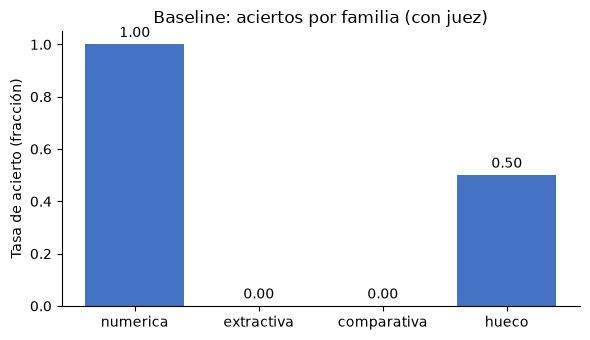

In [11]:
# Gráfico simple de aciertos por familia, leído de resultados/baseline*/resumen.json ya guardados
# (funciona con EJECUTAR=False: no depende de las celdas de arriba, solo de lo que ya hay en disco).
import matplotlib.pyplot as plt


def _tasa(kn):
    if not isinstance(kn, str) or "/" not in kn:
        return None
    k, n = kn.split("/")
    return int(k) / int(n) if int(n) else None


ruta_resumen_baseline = config.RESULTADOS / "baseline" / "resumen.json"
ruta_resumen_baseline_huecos = config.RESULTADOS / "baseline_huecos" / "resumen.json"
resumen_baseline = json.loads(ruta_resumen_baseline.read_text(encoding="utf-8")) if ruta_resumen_baseline.is_file() else {}
resumen_baseline_huecos = json.loads(ruta_resumen_baseline_huecos.read_text(encoding="utf-8")) if ruta_resumen_baseline_huecos.is_file() else {}

familias_baseline = resumen_baseline.get("familias", {})
tasa_hueco = (resumen_baseline_huecos.get("familias") or {}).get("hueco")
etiquetas_familia = ["numerica", "extractiva", "comparativa", "hueco"]
valores_familia = [_tasa(familias_baseline.get("numerica")), _tasa(familias_baseline.get("extractiva")),
                   _tasa(familias_baseline.get("comparativa")), _tasa(tasa_hueco)]

if any(v is not None for v in valores_familia):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    barras = ax.bar(etiquetas_familia, [v if v is not None else 0 for v in valores_familia], color="#4472c4")
    ax.bar_label(barras, labels=[f"{v:.2f}" if v is not None else "n/d" for v in valores_familia], padding=3)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Tasa de acierto (fracción)")
    ax.set_title("Baseline: aciertos por familia (con juez)")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Sin resumen guardado todavía: ejecuta con EJECUTAR=True o espera a que existan resultados/baseline*/resumen.json.")

## 7. Los jueces: etapa 2 de (a) y `correcta`

Dos jueces de un solo criterio, mismo modelo que el agente a temperatura 0.

- **Respaldo**: etiqueta cada frase de la respuesta contra la cita. Aprueba solo
  si todas las que afirman algo están `supported`. Una comparativa respaldada a
  medias suspende.
- **Corrección**: compara la respuesta con `respuesta_esperada`. El formato puede
  variar; la unidad, la escala y el ejercicio no.

La caché hace que re-puntuar cueste 0 llamadas. Los fallos no se cachean, así que
un límite de tasa se reintenta solo en lo que falló.

In [12]:
if EJECUTAR and predicciones.is_file():
    juez = evaluadores.crear_juez(MODELO)
    print(f"Juez: {juez.modelo_id} · {len(juez.cache)} veredictos en caché\n")

    tabla = evaluadores.puntuar(ETIQUETA, juez=juez, estricto=True)
    display(tabla[["id", "familia", "a", "a_existe", "a_vista", "a_respalda",
                   "correcta", "b", "c", "acierto"]])

    print(f"\njuez: {juez.llamadas} llamadas, {juez.fallos} fallos")
    if juez.fallos:
        print("Vuelve a ejecutar esta celda: los fallos no se cachean y se reintentan.")

In [13]:
if EJECUTAR and huecos_pred.is_file():
    tabla_h = evaluadores.puntuar(f"{ETIQUETA}_huecos", juez=juez, estricto=True)
    display(tabla_h[["id", "familia", "abstiene", "sin_cifra", "c", "acierto"]])